In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('TSLA','ANET'), 
         ('TSLA','UAL'), 
         ('TSLA','PWR'), 
         ('AMD','ANET'), 
         ('AMD', 'UAL'),
         ('AMD', 'PWR'), 
         ('TER','ANET'), 
         ('TER', 'UAL'), 
         ('TER','PWR')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=6, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, 

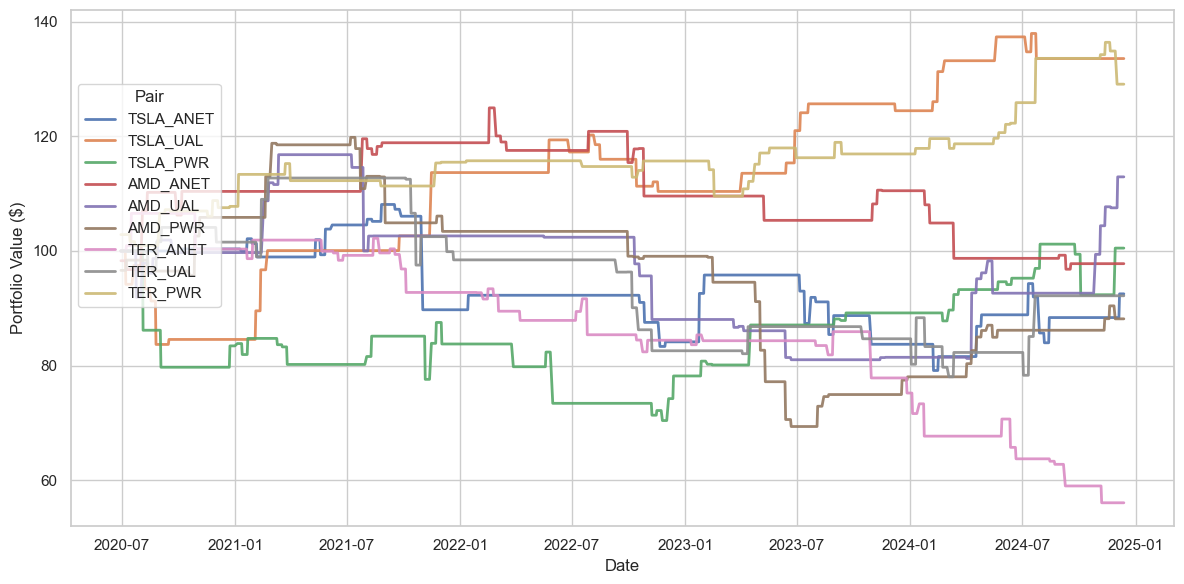

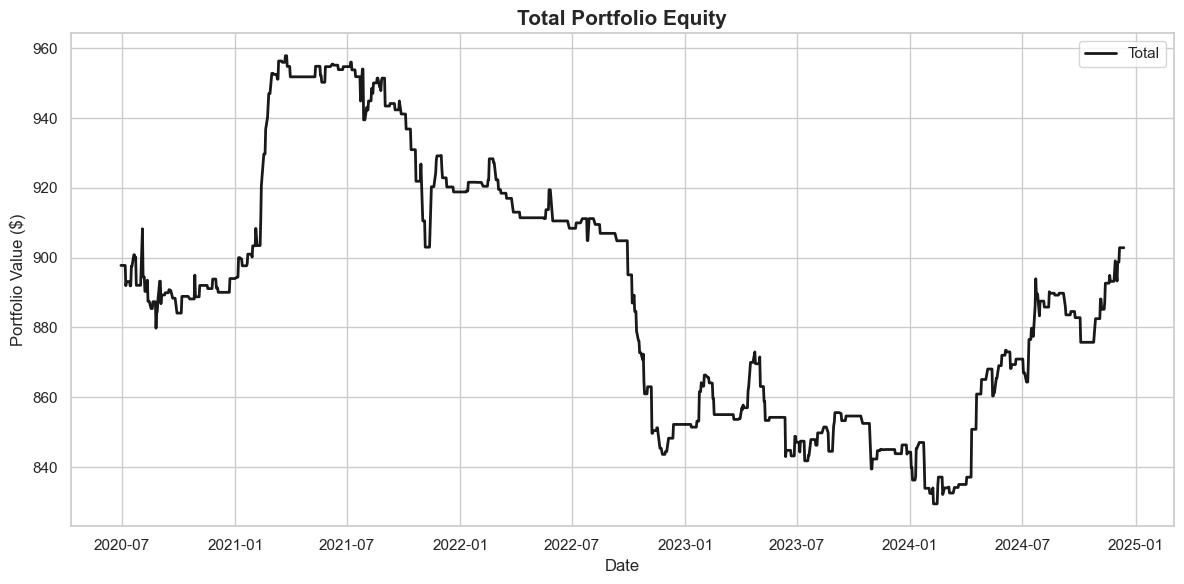

Summary
TSLA_ANET: Final Value = $92.53, Total Return = -7.47%, Trades = 40
TSLA_UAL: Final Value = $133.56, Total Return = 33.56%, Trades = 32
TSLA_PWR: Final Value = $100.50, Total Return = 0.50%, Trades = 42
AMD_ANET: Final Value = $97.79, Total Return = -0.52%, Trades = 30
AMD_UAL: Final Value = $112.93, Total Return = 12.93%, Trades = 36
AMD_PWR: Final Value = $88.17, Total Return = -8.75%, Trades = 44
TER_ANET: Final Value = $56.10, Total Return = -43.90%, Trades = 45
TER_UAL: Final Value = $92.19, Total Return = -7.81%, Trades = 30
TER_PWR: Final Value = $129.09, Total Return = 25.50%, Trades = 46

Total Portfolio Performance
Initial Portfolio Value: $897.78
Final Portfolio Value:   $902.85
Total Return:            0.56%

Sharpe Ratios
TSLA_ANET: Sharpe Ratio = -0.06
TSLA_UAL: Sharpe Ratio = 0.65
TSLA_PWR: Sharpe Ratio = 0.08
AMD_ANET: Sharpe Ratio = 0.04
AMD_UAL: Sharpe Ratio = 0.26
AMD_PWR: Sharpe Ratio = -0.12
TER_ANET: Sharpe Ratio = -1.08
TER_UAL: Sharpe Ratio = -0.07
TER_P

In [5]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)